In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
fish = pd.read_csv('/Users/hye0n0/통계/고등어/ts_train.csv')

In [4]:
fish_na = pd.read_csv('/Users/hye0n0/통계/고등어/ts_train_na.csv')

In [5]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  96 non-null     object 
 1   0           96 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [6]:
fish.set_index('Unnamed: 0', inplace=True)

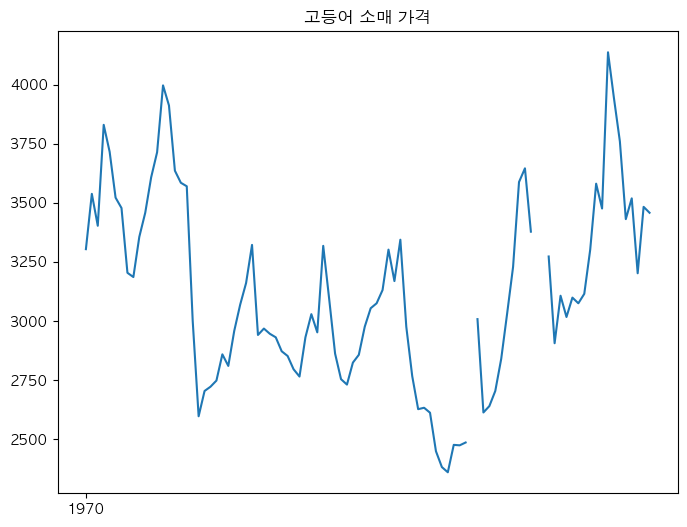

In [7]:
fish_na.index = pd.to_datetime(fish_na.index)
plt.figure(figsize=(8,6))
plt.plot(fish_na.index, fish_na['0'])
plt.title('고등어 소매 가격')
fish.index = pd.to_datetime(fish.index)
plt.savefig('price_na.png', dpi=300)

In [8]:
fish.index = pd.to_datetime(fish.index)

In [9]:
fish['ym']= fish.index

In [10]:
fish['ym'] = fish['ym'].dt.to_period(freq = 'M')

In [11]:
fish['ym'] = fish['ym'].astype('str')

In [12]:
fish.rename(columns={'0':'price'}, inplace=True)

In [19]:
fish

,price,ym,1y
Unnamed: 0,,,
2014-01-01,3304.0,1401,NaN
2014-02-01,3538.0,1402,NaN
2014-03-01,3403.0,1403,NaN
2014-04-01,3830.0,1404,NaN
2014-05-01,3716.0,1405,NaN
...,...,...,...
2021-08-01,3431.0,2108,3420.250000
2021-09-01,3519.0,2109,3454.583333
2021-10-01,3202.0,2110,3470.000000


In [14]:
import re
p = re.compile('\d')

In [15]:
fish['ym'] = fish['ym'].apply(lambda x: ''.join(p.findall(str(x)))[2:])

In [16]:
fish['1y'] = fish['price'].rolling(window=12).mean()

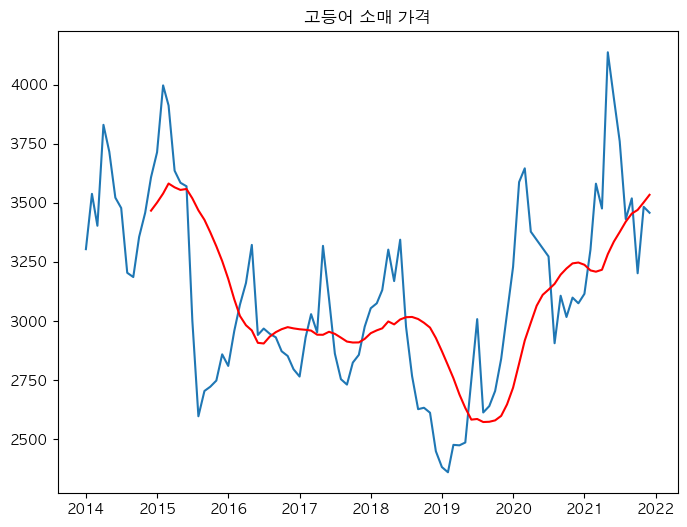

In [17]:
plt.figure(figsize=(8,6))
plt.plot(fish.index, fish['price'])
plt.title('고등어 소매 가격')
plt.plot(fish.index, fish['1y'], color='red')
#plt.savefig('price.png', dpi=300)

In [18]:
fish.describe()

,price,1y
count,96.000000,85.000000
mean,3121.336236,3070.725828
std,395.138353,273.688606
min,2360.000000,2572.606557
25%,2836.000000,2928.250000
50%,3075.000000,2992.583333
75%,3410.000000,3247.416667
max,4137.000000,3581.750000


In [158]:
fish['price'].skew()


0.2919829623888419

In [159]:
fish['price'].kurtosis()

-0.4591385447927854

In [160]:
395.138353/3121.336236

0.12659269079782662

In [161]:
(4137.000000/2360)/2360*100


0.07427822464808963

In [58]:
temp = pd.read_csv('/Users/hye0n0/통계/고등어/해양기상.csv', encoding='utf-8')

In [59]:
temp = temp.iloc[:, [1, 2, 3]]

In [53]:
temp.set_index('일시', inplace=True)

In [60]:
temp

,일시,평균 수온(°C),평균 유의 파고(m)
0,2013.1.1,12.7,1.3
1,2013.1.2,12.1,1.7
2,2013.1.3,10.3,1.1
3,2013.1.4,11.5,1.0
4,2013.1.5,11.8,0.8
...,...,...,...
186545,2022.11.23,19.7,2.3
186546,2022.11.24,19.0,1.0
186547,2022.11.25,19.0,0.7
186548,2022.11.26,18.4,0.4


In [114]:
temp[['평균 수온(°C)','평균 유의 파고(m)']].describe()

,평균 수온(°C),평균 유의 파고(m)
count,183925.000000,185582.000000
mean,16.529452,0.592471
std,6.002242,0.467380
min,-1.400000,0.000000
25%,12.300000,0.300000
50%,16.400000,0.500000
75%,21.300000,0.800000
max,122.000000,6.000000


In [85]:
16.529452 + 6.002242

22.531693999999998

In [86]:
16.529452 - 6.002242

10.52721

In [99]:
0.592471 + 0.467380

1.059851

In [100]:
0.592471 - 0.467380

0.12509099999999995

In [64]:
temp['일시'] = pd.to_datetime(temp['일시'])

In [65]:
temp['m']=temp['일시'].dt.to_period(freq = 'M')

In [119]:
temp_mean = temp.groupby(temp['m']).mean()   

In [120]:
temp_mean=temp_mean.iloc[6:,:]

In [ ]:
temp_mean

In [125]:
temp_mean.describe()

,평균 수온(°C),평균 유의 파고(m)
count,113.000000,113.000000
mean,16.623173,0.597504
std,5.390446,0.111691
min,7.384626,0.380778
25%,11.586766,0.506070
50%,16.294147,0.586975
75%,21.566088,0.683119
max,26.088286,0.890521


In [174]:
temp_mean.kurtosis()

평균 수온(°C)     -1.341640
평균 유의 파고(m)   -0.555514
dwh           -1.646375
dwt           -2.020251
dtype: float64

In [133]:
16.623173+5.390446

22.013619000000002

In [134]:
16.623173-5.390446

11.232727

In [128]:
0.597504+0.111691

0.709195

In [130]:
0.597504-0.111691

0.48581300000000005

In [95]:
temp_mean.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 113 entries, 2013-07 to 2022-11
Freq: M
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   평균 수온(°C)    113 non-null    float64
 1   평균 유의 파고(m)  113 non-null    float64
 2   dwt          113 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.5 KB


In [135]:
temp_mean['dwt']=(11.232727 > temp_mean['평균 수온(°C)']) | (temp_mean['평균 수온(°C)'] > 22.013619000000002)

In [131]:
temp_mean['dwh']=(0.48581300000000005 >  temp_mean['평균 유의 파고(m)']) | (temp_mean['평균 유의 파고(m)'] > 0.709195)

In [138]:
temp_mean['dwh'] = temp_mean['dwh'].astype(int)
temp_mean['dwt'] = temp_mean['dwt'].astype(int)

In [132]:
temp_mean['dwh'].sum()

40

In [140]:
ts = pd.read_csv('/Users/hye0n0/통계/고등어/ts_train.csv')

In [141]:
pd.mear

,Unnamed: 0,0
0,2014-01-01,3304.0
1,2014-02-01,3538.0
2,2014-03-01,3403.0
3,2014-04-01,3830.0
4,2014-05-01,3716.0
...,...,...
91,2021-08-01,3431.0
92,2021-09-01,3519.0
93,2021-10-01,3202.0
94,2021-11-01,3483.0


In [145]:
t=np.arange(1,97)

In [146]:
t

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [148]:
temp_mean

,평균 수온(°C),평균 유의 파고(m),dwh,dwt
m,,,,
2013-07,22.339106,0.616945,0,1
2013-08,25.981856,0.484298,1,1
2013-09,24.440275,0.551663,0,1
2013-10,21.566088,0.754446,1,0
2013-11,17.145869,0.744601,1,0
...,...,...,...,...
2022-07,23.393263,0.468708,1,1
2022-08,24.639039,0.541229,0,1
2022-09,22.983177,0.671239,0,1


In [150]:
train=temp_mean.iloc[:96, :]

In [162]:
train=train.reset_index()

In [164]:
price=pd.concat([ts, train], axis=1)

In [166]:
price['t'] = t

In [168]:
price.set_index('Unnamed: 0', inplace=True)

In [170]:
price.rename(columns={'0':'price', '평균 수온(°C)':'평균수온', '평균 유의 파고(m)':'평균유의파고'}, inplace=True)

In [172]:
price.to_csv('/Users/hye0n0/통계/고등어/price.csv')

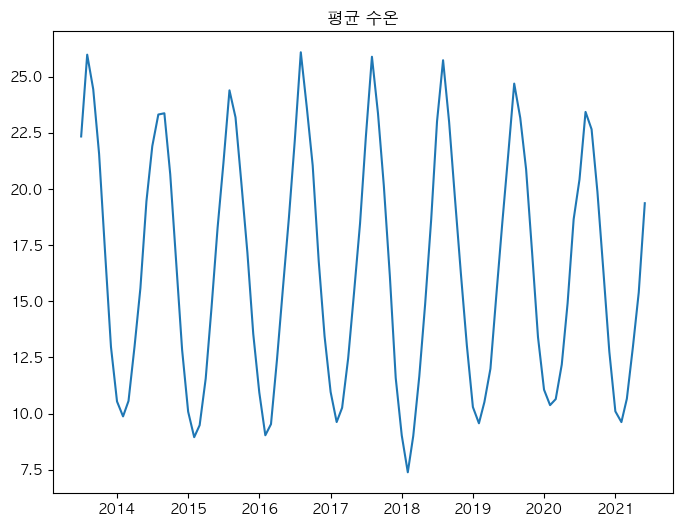

In [12]:
plt.figure(figsize=(8,6))
plt.plot(price['m'], price['평균수온'])
plt.title('평균 수온')
plt.savefig('temp.png', dpi=300)

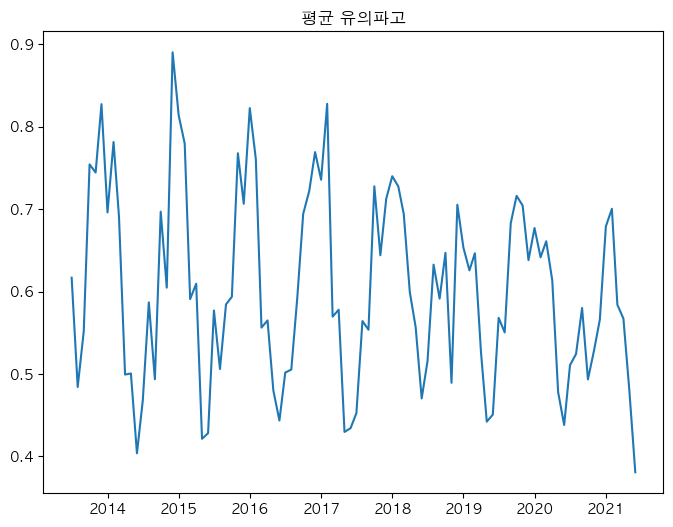

In [13]:
plt.figure(figsize=(8,6))
plt.plot(price['m'], price['평균유의파고'])
plt.title('평균 유의파고')
plt.savefig('h.png', dpi=300)

In [9]:
price['m'] = pd.to_datetime(price['m'])

In [5]:
price= pd.read_csv('/Users/hye0n0/통계/고등어/price.csv')

In [14]:
price

,Unnamed: 0,price,m,평균수온,평균유의파고,dwh,dwt,t
0,2014-01-01,3304.0,2013-07-01,22.339106,0.616945,0,1,1
1,2014-02-01,3538.0,2013-08-01,25.981856,0.484298,1,1,2
2,2014-03-01,3403.0,2013-09-01,24.440275,0.551663,0,1,3
3,2014-04-01,3830.0,2013-10-01,21.566088,0.754446,1,0,4
4,2014-05-01,3716.0,2013-11-01,17.145869,0.744601,1,0,5
...,...,...,...,...,...,...,...,...
91,2021-08-01,3431.0,2021-02-01,9.619111,0.700581,0,1,92
92,2021-09-01,3519.0,2021-03-01,10.660740,0.584154,0,1,93
93,2021-10-01,3202.0,2021-04-01,12.963092,0.567423,0,0,94
94,2021-11-01,3483.0,2021-05-01,15.392731,0.481514,1,0,95


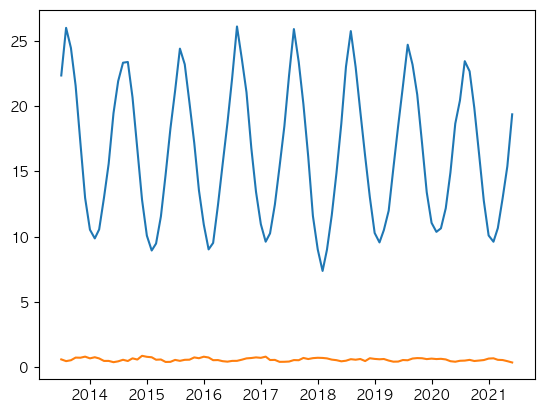

In [17]:
plt.plot(price['m'], price['평균수온'])
plt.plot(price['m'], price['평균유의파고'])

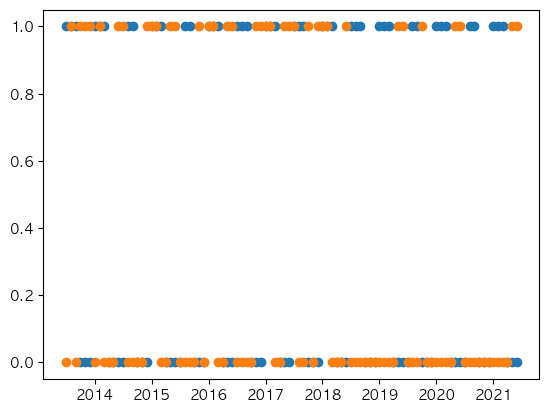

In [24]:
plt.scatter(price['m'], price['dwt']==1)
plt.scatter(price['m'], price['dwh']==1)

In [58]:
price['m'][price['dwt']==1].dt.month.value_counts()

8    8
9    8
1    8
2    8
3    8
7    4
Name: m, dtype: int64

In [59]:
price['m'][price['dwh']==1].dt.month.value_counts()

6     8
5     6
2     5
12    4
1     4
10    3
11    3
7     2
8     1
Name: m, dtype: int64

In [60]:
t=pd.DataFrame(price['m'][price['dwt']==1].dt.month.value_counts())

In [53]:
h=pd.DataFrame(price['m'][price['dwh']==1].dt.month.value_counts())

In [54]:
h

,m
6,8
5,6
2,5
12,4
1,4
10,3
11,3
7,2
8,1


Text(0.5, 1.0, '월별 DWH가 1인 연도 개수')

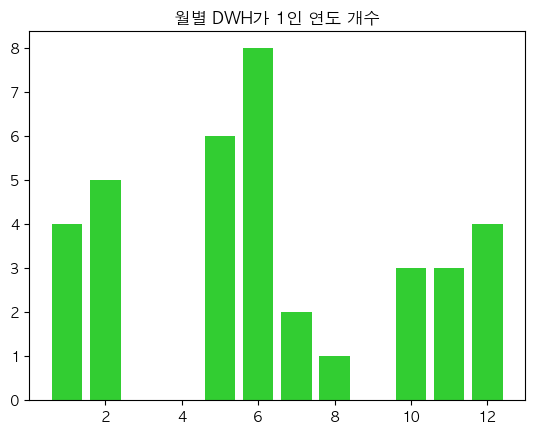

In [70]:
plt.bar(h.index, h['m'], color='limegreen')
plt.title('월별 DWH가 1인 연도 개수')

Text(0.5, 1.0, '월별 DWH가 1인 연도 개수')

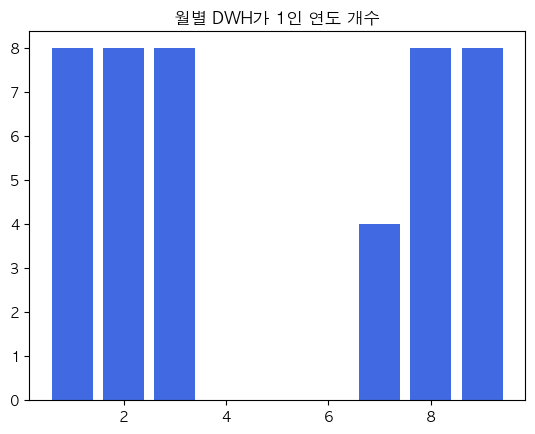

In [71]:
plt.bar(t.index, t['m'], color='royalblue')
plt.title('월별 DWH가 1인 연도 개수')